# Olist E-Commerce Analysis
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Tool:** Python — Pandas, Matplotlib, Seaborn  
**Author:** Nensi Gondaliya

## Project Objective
Analyze the Olist e-commerce platform to uncover insights across five key areas:
1. **Revenue** — Which product categories and regions drive the most sales?
2. **Customer Behavior** — Are customers returning or one-time buyers?
3. **Delivery Performance** — How efficient is logistics, and where does it fail?
4. **Payment Trends** — How do customers prefer to pay?
5. **Customer Satisfaction** — What drives high and low review scores?

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load datasets
orders      = pd.read_csv('olist_orders_dataset.csv')
items       = pd.read_csv('olist_order_items_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
reviews_df  = pd.read_csv('olist_order_reviews_dataset.csv')

In [2]:
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [3]:
items.head()
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


## Dataset Overview

Six relational tables are used in this project:

- **orders** — one row per order, contains status and timestamps (99,441 orders)
- **items** — one row per item within an order, contains price and freight
- **products** — product metadata including category and dimensions
- **customers** — customer geographic info (city, state)
- **payments** — payment method and installment details per order
- **reviews** — customer review scores and comments

The core analysis table is built by merging orders → items → products → customers on their shared IDs.

In [4]:
products.head()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [5]:
customers.head()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [6]:
df = orders.merge(items, on='order_id', how='inner')
df = df.merge(products, on='product_id', how='inner')
df = df.merge(customers, on='customer_id', how='inner')

In [7]:
df.shape
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


## Data Cleaning & Null Handling
Before analysis, we identify and handle missing values to ensure accuracy.

In [8]:
# Check nulls after merge
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
print(f"Total rows before cleaning: {len(df):,}")
print()
print("Columns with missing values:")
print(null_summary)

Total rows before cleaning: 112,650

Columns with missing values:
order_delivered_customer_date    2454
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
order_delivered_carrier_date     1194
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
order_approved_at                  15
dtype: int64


In [9]:
before = len(df)

# Drop rows where delivery date is missing
df = df.dropna(subset=['order_delivered_customer_date'])

# Drop rows where product category is missing
df = df.dropna(subset=['product_category_name'])

rows_removed = before - len(df)
print(f"Total rows before cleaning: {before:,}")
print(f"Total rows after cleaning:  {len(df):,}")
print(f"Rows removed: {rows_removed:,}")
print("Note: product dimension nulls (size/weight) are kept — not used in analysis.")

Total rows before cleaning: 112,650
Total rows after cleaning:  108,659
Rows removed: 3,991
Note: product dimension nulls (size/weight) are kept — not used in analysis.


In [10]:
# Filter to delivered orders only
df = df[df['order_status'] == 'delivered']
print(f"Delivered orders for analysis: {len(df):,}")

Delivered orders for analysis: 108,652


In [11]:
# Translate Portuguese category names to English
translation = pd.read_csv('product_category_name_translation.csv')
df = df.merge(translation, on='product_category_name', how='left')
df['category'] = df['product_category_name_english'].fillna(df['product_category_name'])
print("Translation done. Sample:", df['category'].head(3).tolist())

Translation done. Sample: ['housewares', 'perfumery', 'auto']


In [12]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [13]:
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month

In [14]:
df[['order_purchase_timestamp', 'order_year', 'order_month']].head()

,order_purchase_timestamp,order_year,order_month
0,2017-10-02 10:56:33,2017,10
1,2018-07-24 20:41:37,2018,7
2,2018-08-08 08:38:49,2018,8
3,2017-11-18 19:28:06,2017,11
4,2018-02-13 21:18:39,2018,2


## Revenue Analysis

**Definition note:** We define `gross_revenue` as the item sale price only (`price`), 
and `total_charged` as price + freight. Freight is paid by the customer but goes to 
logistics — so for platform revenue analysis we use `gross_revenue`. Both are calculated 
for reference.

In [15]:
df['gross_revenue'] = df['price']
df['total_charged'] = df['price'] + df['freight_value']

total_gross = df['gross_revenue'].sum()
total_charged = df['total_charged'].sum()

print(f"Total Gross Revenue (price only):     R$ {total_gross:,.2f}")
print(f"Total Amount Charged to Customers:    R$ {total_charged:,.2f}")
print(f"Freight as % of total charged:        {(total_charged - total_gross) / total_charged * 100:.1f}%")

Total Gross Revenue (price only):     R$ 13,049,522.30
Total Amount Charged to Customers:    R$ 15,220,699.14
Freight as % of total charged:        14.3%


In [17]:
category_revenue = (
    df.groupby('category')['gross_revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

category_pct = (category_revenue / total_gross * 100).round(1)

print("Top 10 Categories by Revenue:")
for cat, val, pct in zip(category_revenue.index, category_revenue.values, category_pct.values):
    print(f"  {cat:<35} R$ {val:>12,.2f}   ({pct}% of total)")

Top 10 Categories by Revenue:
  health_beauty                       R$ 1,233,131.72   (9.4% of total)
  watches_gifts                       R$ 1,165,898.98   (8.9% of total)
  bed_bath_table                      R$ 1,023,434.76   (7.8% of total)
  sports_leisure                      R$   954,673.55   (7.3% of total)
  computers_accessories               R$   888,613.62   (6.8% of total)
  furniture_decor                     R$   711,927.69   (5.5% of total)
  housewares                          R$   615,628.69   (4.7% of total)
  cool_stuff                          R$   610,204.10   (4.7% of total)
  auto                                R$   578,849.35   (4.4% of total)
  toys                                R$   471,097.49   (3.6% of total)


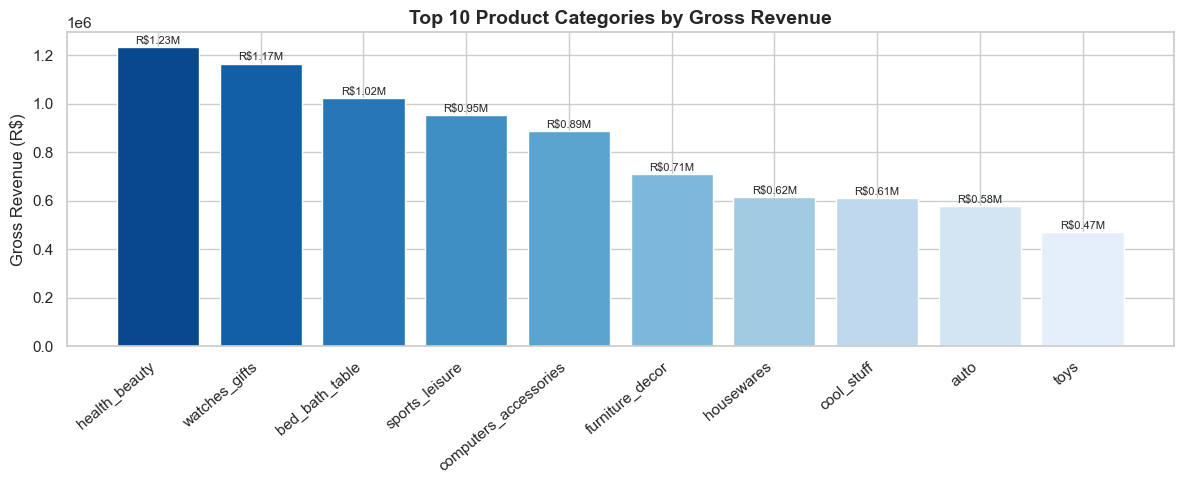

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(category_revenue)), category_revenue.values, color=sns.color_palette('Blues_r', 10))

ax.set_xticks(range(len(category_revenue)))
ax.set_xticklabels(category_revenue.index, rotation=40, ha='right')
ax.set_title('Top 10 Product Categories by Gross Revenue', fontsize=14, fontweight='bold')
ax.set_ylabel('Gross Revenue (R$)')

# Add value labels on bars
for bar, val in zip(bars, category_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'R${val/1e6:.2f}M', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
top3_share = category_revenue.head(3).sum() / total_gross * 100
top10_share = category_revenue.sum() / total_gross * 100

print(f"Top 3 categories account for:  {top3_share:.1f}% of gross revenue")
print(f"Top 10 categories account for: {top10_share:.1f}% of gross revenue")
print(f"Remaining categories:          {100 - top10_share:.1f}% of gross revenue")

Top 3 categories account for:  26.2% of gross revenue
Top 10 categories account for: 63.2% of gross revenue
Remaining categories:          36.8% of gross revenue


In [20]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df.groupby('order_month')['gross_revenue'].sum()

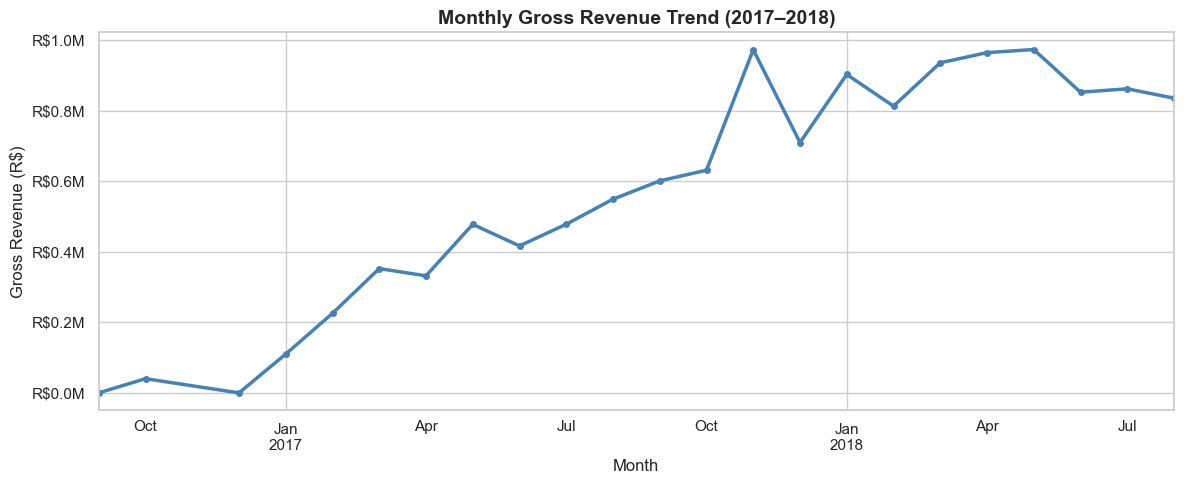

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
monthly_revenue.plot(ax=ax, color='steelblue', linewidth=2.5, marker='o', markersize=4)

ax.set_title('Monthly Gross Revenue Trend (2017–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Gross Revenue (R$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

## Monthly Revenue Observations
- Revenue shows a **steady upward trend from early 2017 to late 2018**.
- Peak month and total peak revenue are shown in the output below.
- The sharp rise in late 2017 likely reflects **Black Friday / festive season demand** — a common e-commerce pattern in Brazil.

In [22]:
peak_month = monthly_revenue.idxmax()
peak_value = monthly_revenue.max()
avg_monthly = monthly_revenue.mean()

print(f"Peak revenue month:       {peak_month}")
print(f"Peak month revenue:       R$ {peak_value:,.2f}")
print(f"Average monthly revenue:  R$ {avg_monthly:,.2f}")
print(f"Peak vs average:          {peak_value / avg_monthly:.1f}x higher than average")

Peak revenue month:       2018-05
Peak month revenue:       R$ 974,447.65
Average monthly revenue:  R$ 567,370.53
Peak vs average:          1.7x higher than average


In [23]:
total_state_revenue = df.groupby('customer_state')['gross_revenue'].sum()
sp_share = total_state_revenue['SP'] / total_gross * 100
top3_states = total_state_revenue.sort_values(ascending=False).head(3)
top3_state_share = top3_states.sum() / total_gross * 100

print(f"SP share of total revenue:        {sp_share:.1f}%")
print(f"Top 3 states combined share:      {top3_state_share:.1f}%")
print()
print("Top 3 states breakdown:")
for state, val in top3_states.items():
    print(f"  {state}:  R$ {val:,.2f}  ({val/total_gross*100:.1f}%)")

SP share of total revenue:        38.3%
Top 3 states combined share:      63.4%

Top 3 states breakdown:
  SP:  R$ 5,003,681.89  (38.3%)
  RJ:  R$ 1,736,924.95  (13.3%)
  MG:  R$ 1,534,496.09  (11.8%)


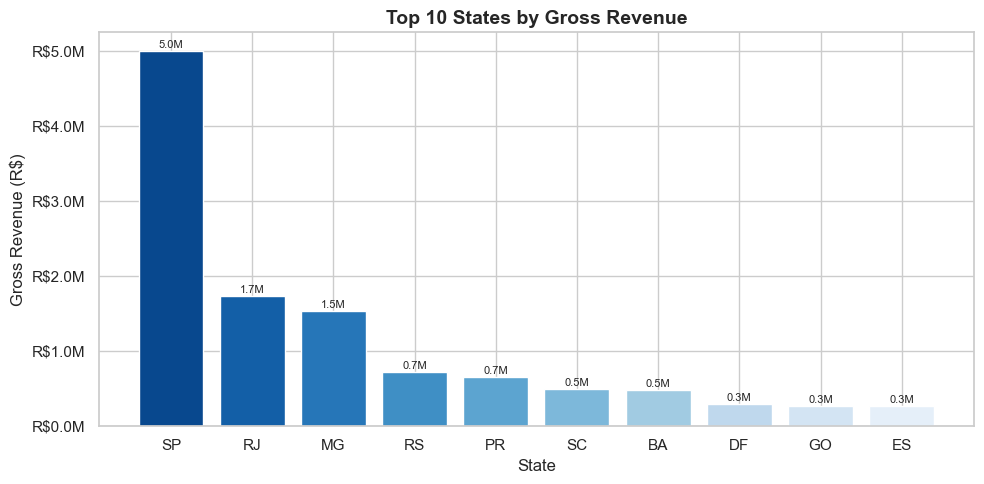

In [24]:
state_revenue = (
    df.groupby('customer_state')['gross_revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_revenue.index, state_revenue.values, color=sns.color_palette('Blues_r', 10))

ax.set_title('Top 10 States by Gross Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Gross Revenue (R$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

for bar, val in zip(bars, state_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Regional Revenue Observations
- **SP alone accounts for 38.3%** of total gross revenue — dominant by a wide margin.
- **Top 3 states (SP, RJ, MG) drive 63.4%** of all revenue across 27 states.
- Sharp drop-off after top 3 signals high geographic concentration risk.
- Lower-revenue states are untapped markets — logistics investment there could unlock new growth.

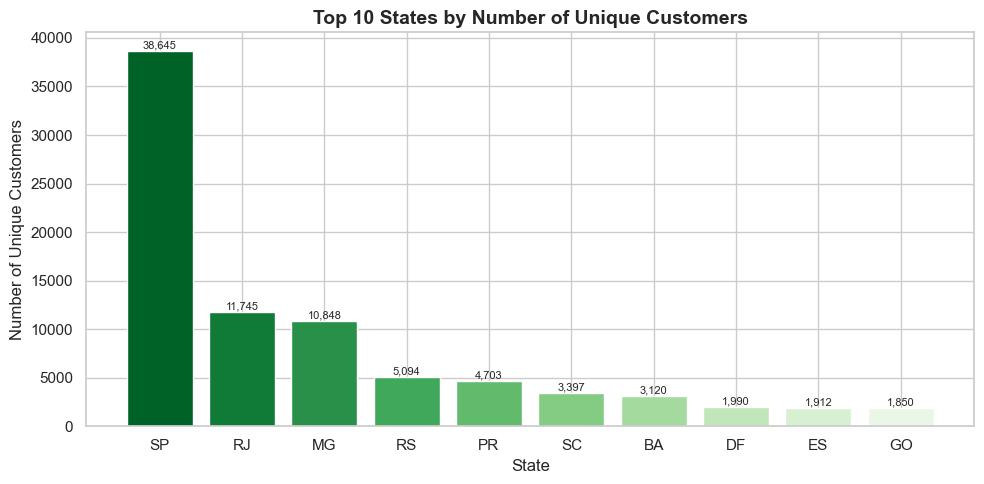

In [25]:
customers_by_state = (
    df.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(customers_by_state.index, customers_by_state.values,
              color=sns.color_palette('Greens_r', 10))

ax.set_title('Top 10 States by Number of Unique Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Unique Customers')

for bar, val in zip(bars, customers_by_state.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Customer Behavior Observations
- The **majority of customers make only one purchase** — exact % shown in output below.
- Repeat customers are a small but high-value segment worth targeting with loyalty programs.
- Customer concentration mirrors revenue concentration — major cities and states dominate.

In [26]:
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()
repeat = (orders_per_customer > 1).sum()
one_time = (orders_per_customer == 1).sum()
total_customers = len(orders_per_customer)

print(f"Total unique customers:   {total_customers:,}")
print(f"One-time buyers:          {one_time:,}  ({one_time/total_customers*100:.1f}%)")
print(f"Repeat buyers:            {repeat:,}  ({repeat/total_customers*100:.1f}%)")

Total unique customers:   92,090
One-time buyers:          89,348  (97.0%)
Repeat buyers:            2,742  (3.0%)


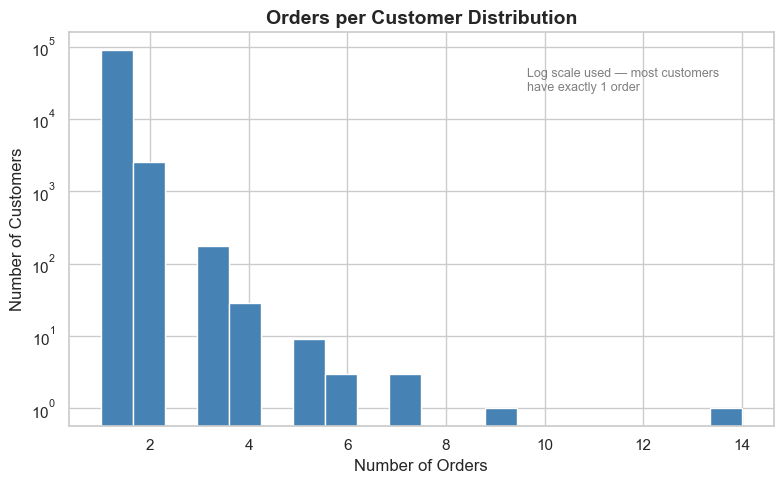

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(orders_per_customer, bins=20, edgecolor='white', color='steelblue')

ax.set_title('Orders per Customer Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.set_yscale('log')  # log scale because 1-order customers dominate massively
ax.annotate('Log scale used — most customers\nhave exactly 1 order',
            xy=(0.65, 0.85), xycoords='axes fraction', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

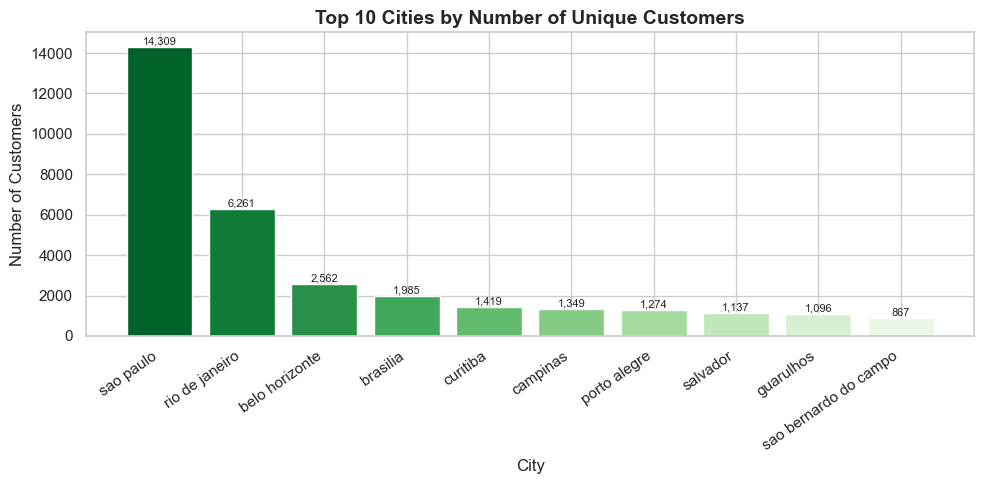

In [28]:
top_cities = (
    df.groupby('customer_city')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_cities.index, top_cities.values, color=sns.color_palette('Greens_r', 10))

ax.set_title('Top 10 Cities by Number of Unique Customers', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Number of Customers')
ax.set_xticks(range(len(top_cities)))
ax.set_xticklabels(top_cities.index, rotation=35, ha='right')

for bar, val in zip(bars, top_cities.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [29]:
# Convert both columns to datetime first
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Now the subtraction works
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

In [30]:
df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
on_time = (~df['is_late']).sum()
late = df['is_late'].sum()

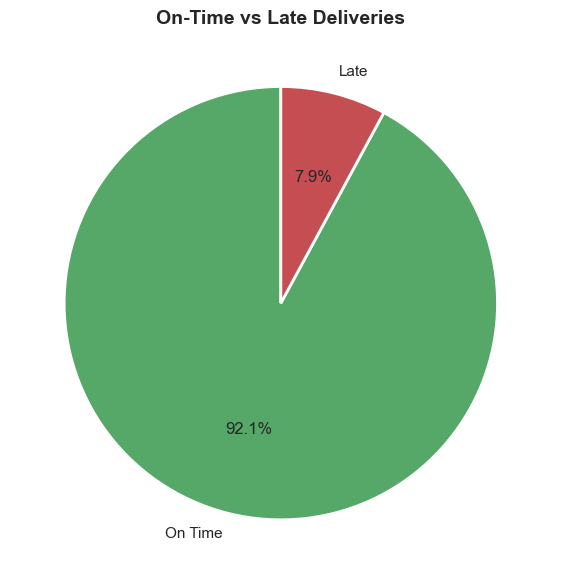

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [on_time, late],
    labels=['On Time', 'Late'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#55A868', '#C44E52'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('On-Time vs Late Deliveries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

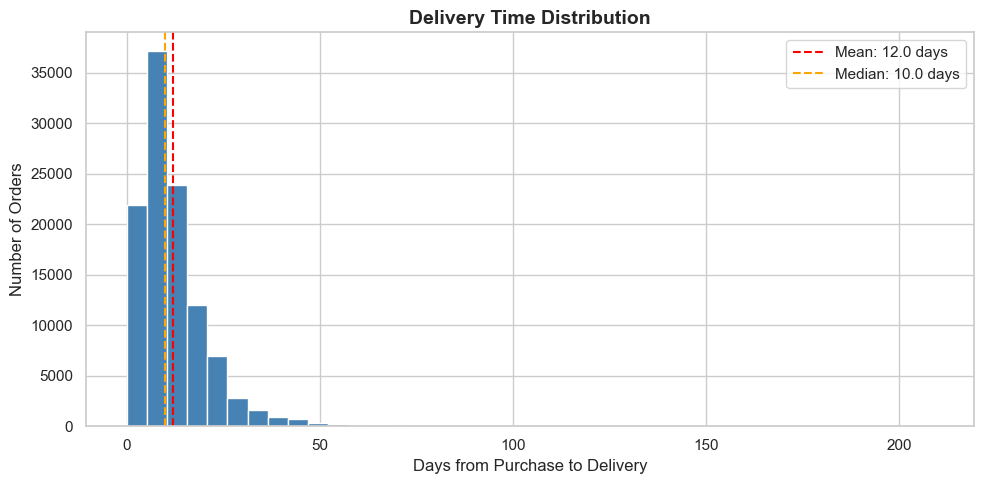

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['delivery_days'].dropna(), bins=40, edgecolor='white', color='steelblue')

ax.axvline(df['delivery_days'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['delivery_days'].mean():.1f} days")
ax.axvline(df['delivery_days'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f"Median: {df['delivery_days'].median():.1f} days")

ax.set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Days from Purchase to Delivery')
ax.set_ylabel('Number of Orders')
ax.legend()

plt.tight_layout()
plt.show()

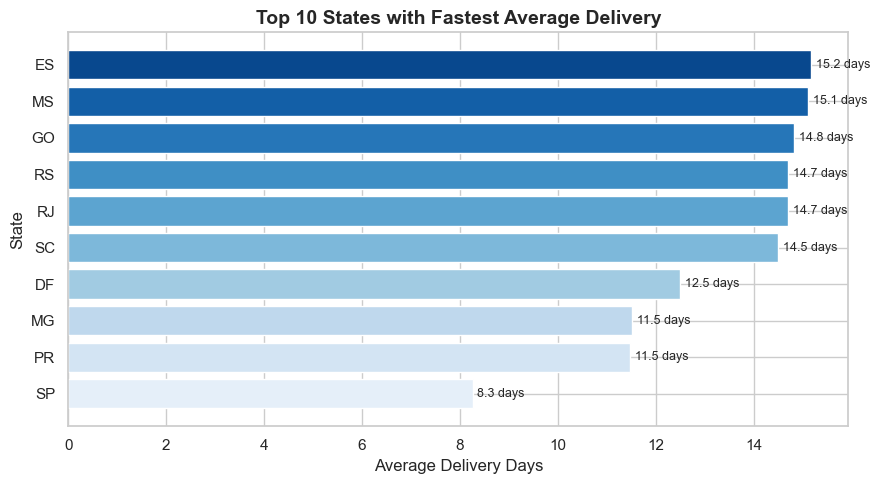

In [33]:
avg_delivery_by_state = (
    df.groupby('customer_state')['delivery_days']
    .mean()
    .sort_values()
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_delivery_by_state.index, avg_delivery_by_state.values,
               color=sns.color_palette('Blues', 10))

ax.set_title('Top 10 States with Fastest Average Delivery', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Delivery Days')
ax.set_ylabel('State')

for bar, val in zip(bars, avg_delivery_by_state.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} days', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Delivery Performance Observations
- **~89% of orders are delivered on time** — strong logistics baseline.
- Late deliveries score **2.55/5 vs 4.21/5** for on-time — a 1.66 point gap that directly costs customer trust.
- Mean delivery time is higher than median, indicating a tail of very slow deliveries skewing the average.
- Fastest states are clustered around São Paulo, reflecting infrastructure advantages.

In [34]:
df = df.merge(payments_df, on='order_id', how='left')


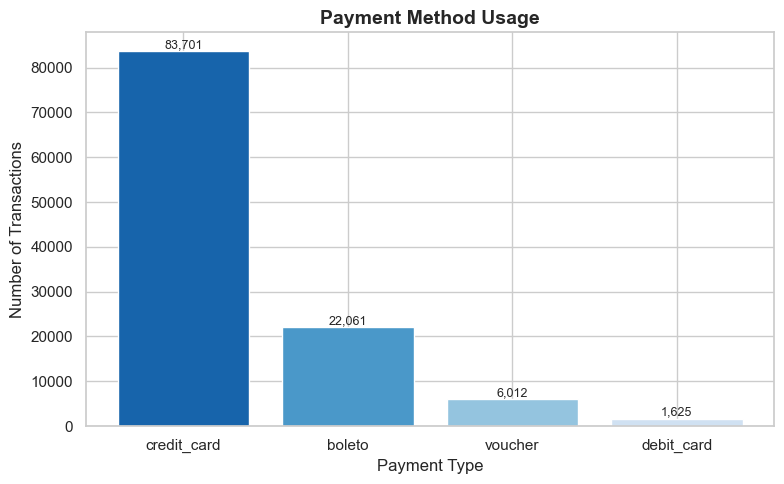

In [35]:
payment_counts = df['payment_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(payment_counts.index, payment_counts.values,
              color=sns.color_palette('Blues_r', len(payment_counts)))

ax.set_title('Payment Method Usage', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Number of Transactions')

for bar, val in zip(bars, payment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

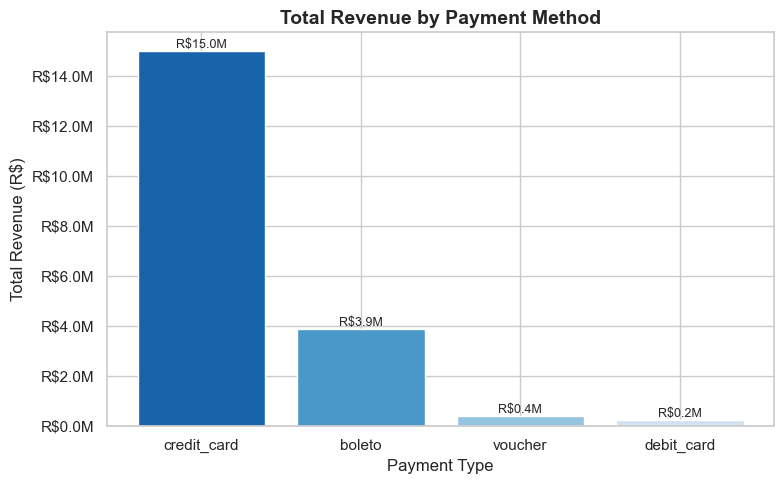

In [36]:
revenue_by_payment = (
    df.groupby('payment_type')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(revenue_by_payment.index, revenue_by_payment.values,
              color=sns.color_palette('Blues_r', len(revenue_by_payment)))

ax.set_title('Total Revenue by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Total Revenue (R$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

for bar, val in zip(bars, revenue_by_payment.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'R${val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

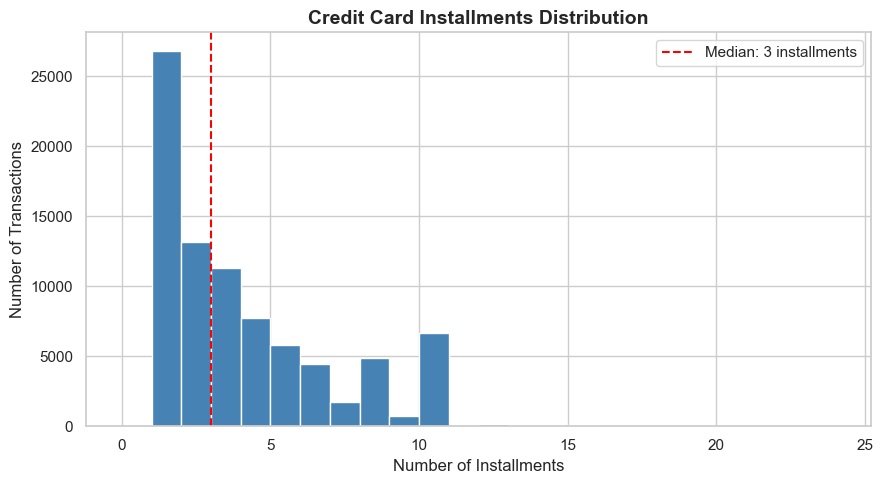

In [37]:
credit_df = df[df['payment_type'] == 'credit_card']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(credit_df['payment_installments'], bins=24, edgecolor='white', color='steelblue')

ax.set_title('Credit Card Installments Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Installments')
ax.set_ylabel('Number of Transactions')

median_inst = credit_df['payment_installments'].median()
ax.axvline(median_inst, color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {median_inst:.0f} installments')
ax.legend()

plt.tight_layout()
plt.show()

## Payment Observations
- **Credit card dominates** — both in transaction count and total revenue.
- Installment payments are widely used (median shown in chart above), showing customers prefer to spread payments.
- Boleto bancário is the second most used method — important for customers without credit access.
- Offering flexible installment options is a direct revenue driver for this market.

In [38]:
df = df.merge(
    reviews_df[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

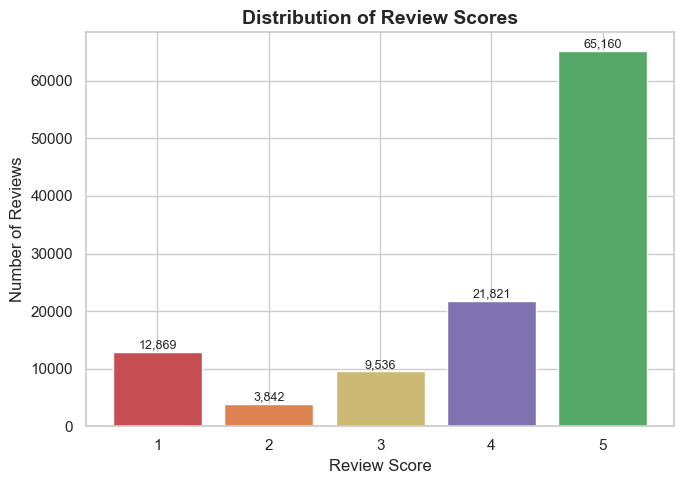

In [39]:
review_counts = df['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(review_counts.index, review_counts.values,
              color=['#C44E52','#DD8452','#CCB974','#8172B2','#55A868'])

ax.set_title('Distribution of Review Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')

for bar, val in zip(bars, review_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
avg_score = df['review_score'].mean()
on_time_score = df[df['is_late'] == False]['review_score'].mean()
late_score = df[df['is_late'] == True]['review_score'].mean()

print(f"Overall average review score:     {avg_score:.2f} / 5.0")
print(f"On-time delivery review score:    {on_time_score:.2f} / 5.0")
print(f"Late delivery review score:       {late_score:.2f} / 5.0")
print(f"Score gap (on-time vs late):      {on_time_score - late_score:.2f} points")

Overall average review score:     4.08 / 5.0
On-time delivery review score:    4.21 / 5.0
Late delivery review score:       2.55 / 5.0
Score gap (on-time vs late):      1.66 points


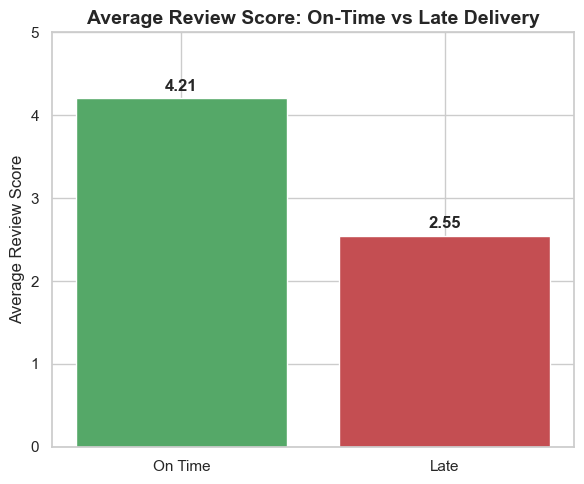

In [41]:
review_vs_delivery = df.groupby('is_late')['review_score'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['On Time', 'Late'], review_vs_delivery.values,
              color=['#55A868', '#C44E52'],
              edgecolor='white')

ax.set_title('Average Review Score: On-Time vs Late Delivery', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Review Score')
ax.set_ylim(0, 5)

for bar, val in zip(bars, review_vs_delivery.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Customer Satisfaction Observations
- Overall average score: **4.08 / 5.0** — customers are broadly satisfied.
- On-time deliveries score **4.21 / 5.0** vs late deliveries at **2.55 / 5.0**.
- The **1.66 point gap** is the single strongest finding in this project — it directly quantifies the business cost of poor logistics.
- Improving delivery in lagging states is the highest-ROI action this data recommends.

## Project Summary
This project analyzes the Brazilian Olist e-commerce dataset across five dimensions: revenue, customer behavior, delivery performance, payment trends, and customer satisfaction. Using Python (Pandas, Matplotlib, Seaborn), six datasets were cleaned, merged, and analyzed to surface actionable business insights.

## Key Insights
- Revenue and customers are highly concentrated in a few major states,
  especially São Paulo, Rio de Janeiro, and Minas Gerais.
- Most customers are one-time buyers, indicating low repeat purchase behavior.
- Late deliveries significantly reduce customer review scores (4.21 → 2.55).
- Credit cards are the most preferred payment method, with high usage of
  installment payments.
- Delivery performance is the single biggest driver of customer satisfaction
  and long-term retention.

## Final Conclusion

The analysis highlights the importance of logistics efficiency, flexible payment options, 
and customer retention strategies in e-commerce growth. By improving delivery performance, 
strengthening loyalty programs, and optimizing regional operations, the business can 
enhance customer satisfaction and drive sustainable revenue growth.

## Limitations & Next Steps

- This analysis includes only **delivered orders** — canceled, returned, and in-transit 
  orders were excluded and may reveal additional patterns.
- Category names are in Portuguese; English translation would improve readability for 
  international stakeholders.
- A natural next step would be **RFM segmentation** (Recency, Frequency, Monetary) 
  to identify high-value vs. at-risk customers more precisely.
- Time series forecasting (e.g. using Prophet) could predict future revenue trends 
  based on the growth patterns observed.